# Quantum-Enhanced Heart Disease Ensemble

## A Reproducible Classical-Quantum Benchmark

This executed notebook is the portfolio-facing analysis for the 2025 IEEE ICITIIT
paper *Prediction of Cardiac Disease Using Quantum Enhanced Ensemble Learning
Approach*. It evaluates whether a bagged quantum-kernel classifier remains
competitive under leakage-safe preprocessing, paired uncertainty, a compute-matched
classical baseline, and cross-hospital dataset shift.

> **Research boundary:** The paper-reported accuracy of **90.16%** is historical
> publication context. It is not claimed as reproduced here. Every new result in this
> notebook comes from the repository's frozen reference protocol.

**Responsible-use notice:** This is a research reproduction, not a diagnostic tool.
The notebook uses only aggregate evidence and must not be used for clinical decisions.

## 1. Load and Verify the Public Evidence

The committed JSON artefact is the single source of truth for this notebook. It
contains aggregate metrics, configuration, provenance, confidence intervals, and
diagnostic summaries—never patient-level rows.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(path for path in candidates if (path / "artifacts/public/results.json").exists())
ARTEFACT = ROOT / "artifacts/public/results.json"
FIGURES = ROOT / "reports/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

with ARTEFACT.open(encoding="utf-8") as stream:
    evidence = json.load(stream)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "navy": "#112c35",
    "teal": "#14766d",
    "coral": "#e36f55",
    "gold": "#e5ba58",
    "grey": "#7b878b",
}

display(Markdown(
    f"**Verified artefact:** `{evidence['artefact_sha256']}`<br>"
    f"**Experiment:** `{evidence['experiment']['experiment_id']}` · "
    f"{evidence['experiment']['folds']}-fold CV · seed "
    f"`{evidence['experiment']['seed']}`"
))

**Verified artefact:** `f672dbec410768b5b3b5cd2db9cbb049b234650c82192826f77ee81610f731ac`<br>**Experiment:** `cleveland-reference-v1` · 5-fold CV · seed `20250913`

## 2. Study Design

The primary evaluation uses five stratified out-of-fold splits on Cleveland. All
imputation, encoding, scaling, and four-component feature reduction are fitted inside
the training fold. ROC AUC intervals use 1,000 deterministic bootstrap resamples.
Quantum and matched RBF models receive the same four-dimensional fold-local
representation.

In [2]:
experiment = pd.Series(evidence["experiment"], name="Frozen protocol").to_frame()
environment = pd.Series(evidence["environment"], name="Recorded environment").to_frame()
display(experiment)
display(environment)

,Frozen protocol
bagging_estimators,7
bootstrap_samples,1000
cohorts,"[cleveland, hungarian, switzerland, long-beach..."
experiment_id,cleveland-reference-v1
fingerprint,c2e50c42dc96518b
folds,5
minimum_subgroup_size,25
quantum_entanglement,linear
quantum_feature_map_reps,2
quantum_features,4


,Recorded environment
numpy,2.5.3
pandas,2.3.3
platform,macOS-15.5-arm64-arm-64bit
python,3.12.14
qiskit,2.5.2
qiskit_machine_learning,0.9.1
scikit_learn,1.7.2


## 3. Dataset and Cohort Profile

The UCI collection contains four historical hospital cohorts. Their large differences
in prevalence and missingness make transportability an essential part of the study.
Raw rows are downloaded from UCI only for a full rerun and are excluded from Git.

In [3]:
cohorts = pd.DataFrame(evidence["dataset"]["cohorts"])
cohort_table = cohorts[[
    "cohort", "rows", "positive_rows", "positive_rate", "missing_cells", "duplicate_rows"
]].copy()
cohort_table["positive_rate"] = cohort_table["positive_rate"].map(lambda value: f"{value:.1%}")
cohort_table.columns = [
    "Cohort", "Rows", "Positive Rows", "Positive Rate", "Missing Cells", "Duplicate Rows"
]
display(HTML(cohort_table.style.hide(axis="index").set_uuid("cohorts").to_html()))

Cohort,Rows,Positive Rows,Positive Rate,Missing Cells,Duplicate Rows
cleveland,303,139,45.9%,6,0
hungarian,294,106,36.1%,782,1
switzerland,123,115,93.5%,273,0
long-beach-va,200,149,74.5%,698,1


## 4. Benchmark Results

The leaderboard reports out-of-fold discrimination, class-balanced performance,
probability quality, and runtime. Confidence intervals make uncertainty visible instead
of reducing the experiment to a single winning score.

Model,Track,ROC AUC,Balanced Accuracy,Brier Score,ECE,Runtime (s)
Logistic Regression,Classical,0.895,0.809,0.129,0.050,0.06
Extra Trees,Classical,0.893,0.821,0.132,0.073,0.95
RBF-SVC (Full),Classical,0.881,0.813,0.136,0.031,0.10
Histogram Gradient Boosting,Classical,0.869,0.784,0.155,0.095,2.31
RBF-SVC (Matched 4D),Classical,0.856,0.785,0.152,0.047,0.07
Bagged Quantum-Kernel SVC,Quantum,0.661,0.598,0.235,0.083,1.80
Quantum-Kernel SVC,Quantum,0.647,0.596,0.232,0.029,1.72
Dummy Prior,Classical,0.495,0.500,0.248,0.000,0.03


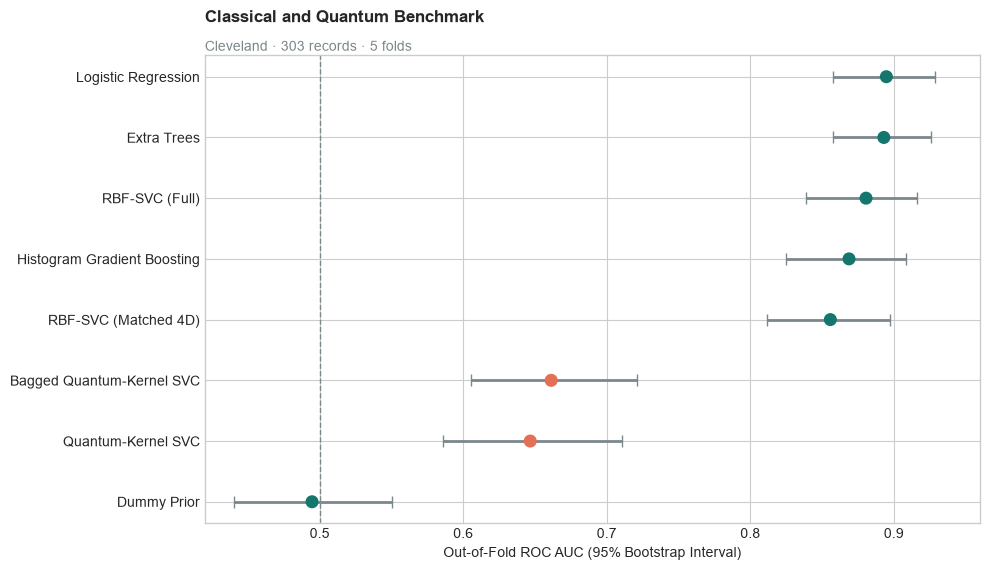

In [4]:
MODEL_LABELS = {
    "logistic_regression": "Logistic Regression",
    "extra_trees": "Extra Trees",
    "rbf_svc": "RBF-SVC (Full)",
    "hist_gradient_boosting": "Histogram Gradient Boosting",
    "rbf_svc_4d": "RBF-SVC (Matched 4D)",
    "bagged_quantum_kernel_svc": "Bagged Quantum-Kernel SVC",
    "quantum_kernel_svc": "Quantum-Kernel SVC",
    "dummy_prior": "Dummy Prior",
}

leaderboard = pd.DataFrame(evidence["leaderboard"])
leaderboard["Model"] = leaderboard["model"].map(MODEL_LABELS)
leaderboard["Track"] = leaderboard["track"].str.title()
results_table = leaderboard[[
    "Model", "Track", "roc_auc", "balanced_accuracy", "brier", "ece", "runtime_seconds"
]].rename(columns={
    "roc_auc": "ROC AUC",
    "balanced_accuracy": "Balanced Accuracy",
    "brier": "Brier Score",
    "ece": "ECE",
    "runtime_seconds": "Runtime (s)",
})
result_style = results_table.style.hide(axis="index").format({
    "ROC AUC": "{:.3f}", "Balanced Accuracy": "{:.3f}",
    "Brier Score": "{:.3f}", "ECE": "{:.3f}", "Runtime (s)": "{:.2f}"
}).set_uuid("leaderboard")
display(HTML(result_style.to_html()))

ordered = leaderboard.iloc[::-1].reset_index(drop=True)
auc = ordered["roc_auc"].to_numpy()
lower = np.array([item["lower"] for item in ordered["roc_auc_interval"]])
upper = np.array([item["upper"] for item in ordered["roc_auc_interval"]])
colours = [COLORS["coral"] if track == "quantum" else COLORS["teal"] for track in ordered["track"]]

fig, ax = plt.subplots(figsize=(10, 5.8))
y = np.arange(len(ordered))
ax.errorbar(
    auc,
    y,
    xerr=[auc - lower, upper - auc],
    fmt="none",
    ecolor=COLORS["grey"],
    capsize=4,
    lw=2,
)
ax.scatter(auc, y, c=colours, s=70, zorder=3)
ax.set_yticks(y, ordered["Model"])
ax.axvline(0.5, color=COLORS["grey"], ls="--", lw=1, label="Chance")
ax.set_xlim(0.42, 0.96)
ax.set_xlabel("Out-of-Fold ROC AUC (95% Bootstrap Interval)")
ax.set_title("Classical and Quantum Benchmark", loc="left", weight="bold", pad=24)
ax.text(
    0.0,
    1.01,
    "Cleveland · 303 records · 5 folds",
    color=COLORS["grey"],
    transform=ax.transAxes,
)
fig.tight_layout()
fig.savefig(FIGURES / "model_auc_forest.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Primary Matched Comparison

The primary claim test compares the bagged quantum-kernel SVC with an RBF-SVC using
the same four-component representation. A positive paired difference would favour the
quantum method.

In [5]:
comparison = evidence["primary_comparison"]
display(Markdown(
    "### No Quantum Advantage Was Demonstrated<br><br>"
    f"The paired ROC AUC difference was **{comparison['estimate']:+.3f}** "
    f"(95% interval **{comparison['lower']:+.3f} to {comparison['upper']:+.3f}**). "
    f"The bootstrap probability that the quantum model was better was "
    f"**{comparison['probability_first_better']:.1%}**. Because the complete interval "
    "is below zero, the result favours the compute-matched classical baseline under "
    "this protocol."
))

### No Quantum Advantage Was Demonstrated<br><br>The paired ROC AUC difference was **-0.194** (95% interval **-0.256 to -0.133**). The bootstrap probability that the quantum model was better was **0.0%**. Because the complete interval is below zero, the result favours the compute-matched classical baseline under this protocol.

## 6. Probability Calibration

Calibration compares predicted probability with observed frequency. The diagonal is
ideal. These curves are descriptive because each bin contains a limited number of
out-of-fold observations.

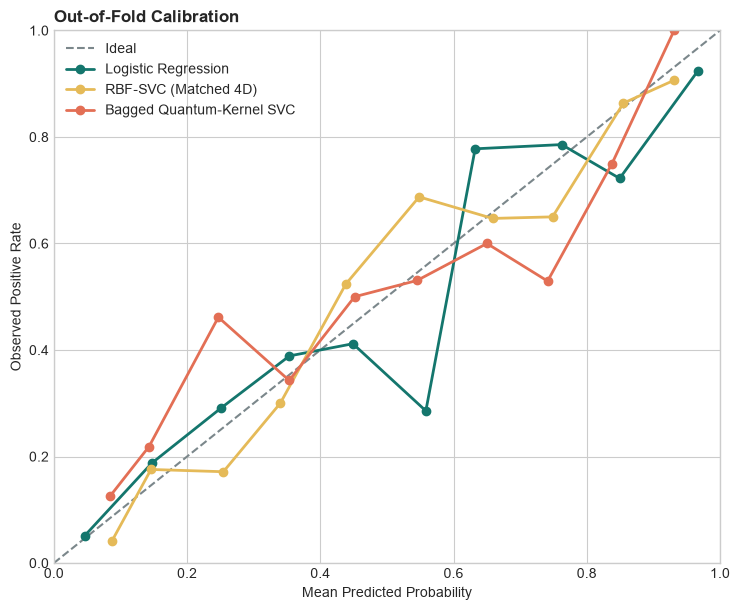

In [6]:
selected_models = ["logistic_regression", "rbf_svc_4d", "bagged_quantum_kernel_svc"]
selected_colours = [COLORS["teal"], COLORS["gold"], COLORS["coral"]]

fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.plot([0, 1], [0, 1], color=COLORS["grey"], ls="--", label="Ideal")
for model, colour in zip(selected_models, selected_colours, strict=True):
    frame = pd.DataFrame(evidence["calibration"][model])
    ax.plot(frame["mean_probability"], frame["observed_rate"], marker="o", lw=2,
            color=colour, label=MODEL_LABELS[model])
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean Predicted Probability",
       ylabel="Observed Positive Rate")
ax.set_title("Out-of-Fold Calibration", loc="left", weight="bold")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES / "calibration_curves.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Quantum-Kernel Diagnostics

Kernel-target alignment measures how strongly the kernel geometry reflects the class
structure. Effective rank summarises spectral complexity. These diagnostics help
explain *why* a quantum model does or does not perform well, rather than treating the
circuit as a black box.

fold,qubits,feature_map_reps,kernel_target_alignment,effective_rank,condition_proxy,kernel_seconds
0,4,2,0.055,89.1,"141,848",0.371
1,4,2,0.062,90.9,"698,928",0.323
2,4,2,0.044,90.0,"228,196",0.366
3,4,2,0.060,87.0,"490,972",0.335
4,4,2,0.055,85.2,"380,032",0.309


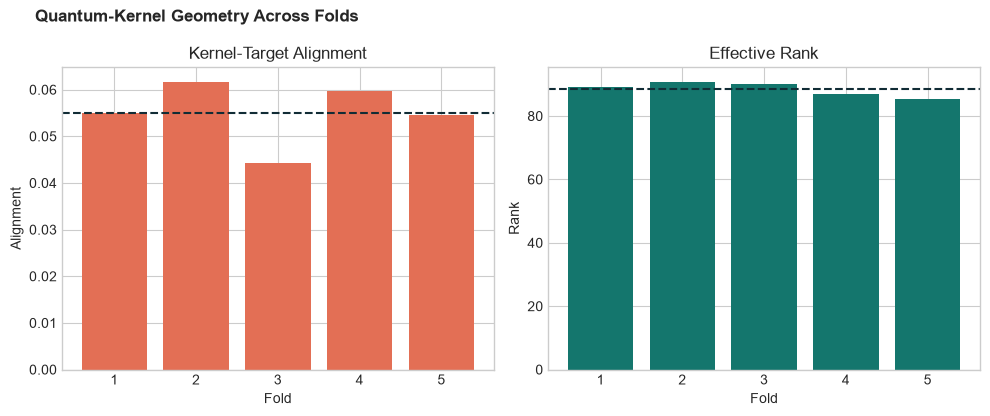

Mean target alignment was **0.055** and mean effective rank was **88.4**. The weak alignment is consistent with the quantum model's limited discrimination on this representation.

In [7]:
diagnostics = pd.DataFrame(evidence["quantum_diagnostics"])
diagnostic_style = diagnostics[[
    "fold", "qubits", "feature_map_reps", "kernel_target_alignment",
    "effective_rank", "condition_proxy", "kernel_seconds"
]].style.hide(axis="index").format({
    "kernel_target_alignment": "{:.3f}", "effective_rank": "{:.1f}",
    "condition_proxy": "{:,.0f}", "kernel_seconds": "{:.3f}"
}).set_uuid("diagnostics")
display(HTML(diagnostic_style.to_html()))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
fold_number = diagnostics["fold"] + 1
axes[0].bar(fold_number, diagnostics["kernel_target_alignment"], color=COLORS["coral"])
axes[0].axhline(diagnostics["kernel_target_alignment"].mean(), color=COLORS["navy"], ls="--")
axes[0].set(title="Kernel-Target Alignment", xlabel="Fold", ylabel="Alignment")
axes[1].bar(fold_number, diagnostics["effective_rank"], color=COLORS["teal"])
axes[1].axhline(diagnostics["effective_rank"].mean(), color=COLORS["navy"], ls="--")
axes[1].set(title="Effective Rank", xlabel="Fold", ylabel="Rank")
fig.suptitle("Quantum-Kernel Geometry Across Folds", x=0.04, ha="left", weight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "quantum_kernel_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(
    f"Mean target alignment was **{diagnostics['kernel_target_alignment'].mean():.3f}** "
    f"and mean effective rank was **{diagnostics['effective_rank'].mean():.1f}**. "
    "The weak alignment is consistent with the quantum model's limited discrimination "
    "on this representation."
))

## 8. Cross-Hospital Transportability

Each row is a training cohort and each column is a test cohort. Diagonal cells are
**resubstitution**, not external validation, so they are shown only as apparent fit.
Off-diagonal cells reveal how performance changes across hospitals.

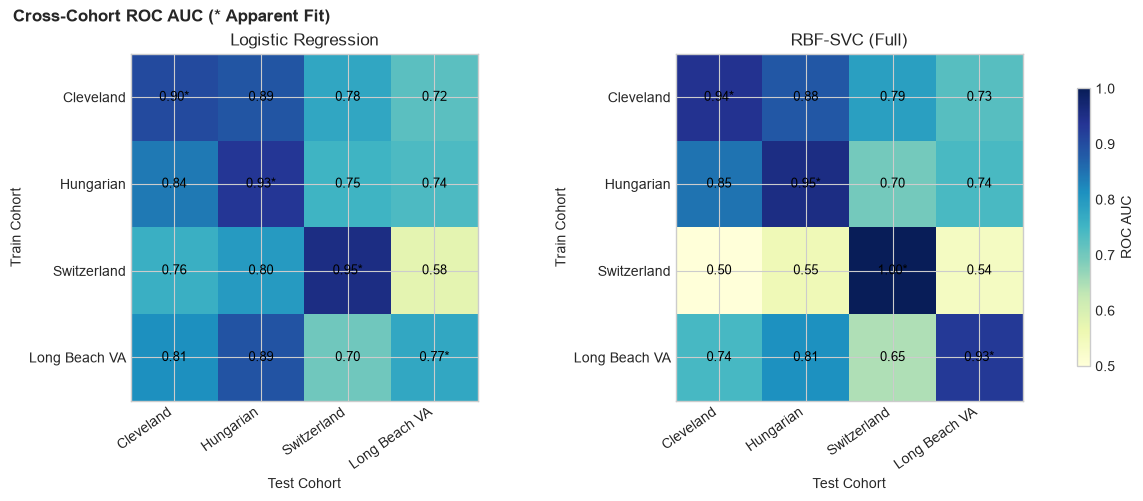

In [8]:
transport = pd.DataFrame(evidence["transportability"])
cohort_order = ["cleveland", "hungarian", "switzerland", "long-beach-va"]
cohort_labels = ["Cleveland", "Hungarian", "Switzerland", "Long Beach VA"]
transport_models = ["logistic_regression", "rbf_svc"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.9), constrained_layout=True)

for ax, model in zip(axes, transport_models, strict=True):
    matrix = (transport[transport["model"] == model]
              .pivot(index="train_cohort", columns="test_cohort", values="roc_auc")
              .reindex(index=cohort_order, columns=cohort_order))
    image = ax.imshow(matrix, vmin=0.5, vmax=1.0, cmap="YlGnBu")
    for row in range(len(cohort_order)):
        for column in range(len(cohort_order)):
            suffix = "*" if row == column else ""
            ax.text(column, row, f"{matrix.iloc[row, column]:.2f}{suffix}",
                    ha="center", va="center", color="black", fontsize=9)
    ax.set_xticks(range(4), cohort_labels, rotation=35, ha="right")
    ax.set_yticks(range(4), cohort_labels)
    ax.set(xlabel="Test Cohort", ylabel="Train Cohort", title=MODEL_LABELS[model])
fig.colorbar(image, ax=axes, label="ROC AUC", shrink=0.8)
fig.suptitle("Cross-Cohort ROC AUC (* Apparent Fit)", x=0.06, ha="left", weight="bold")
fig.savefig(FIGURES / "transportability_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Subgroup Audit

The audit reports descriptive performance for sex and age groups with at least 25
records. It does not establish fairness or clinical safety; the historical sample is
too small and unrepresentative for such a claim.

In [9]:
subgroup = pd.DataFrame(evidence["subgroup_metrics"])
subgroup = subgroup[subgroup["model"].isin([
    "logistic_regression", "bagged_quantum_kernel_svc"
])].copy()
subgroup["Model"] = subgroup["model"].map(MODEL_LABELS)
subgroup["Group"] = subgroup["group"].str.replace("_", " ").str.title()
subgroup_style = subgroup[[
    "Model", "Group", "rows", "positive_rows", "roc_auc", "balanced_accuracy", "brier"
]].rename(columns={
    "rows": "Rows", "positive_rows": "Positive Rows", "roc_auc": "ROC AUC",
    "balanced_accuracy": "Balanced Accuracy", "brier": "Brier Score"
}).style.hide(axis="index").format({
    "ROC AUC": "{:.3f}", "Balanced Accuracy": "{:.3f}", "Brier Score": "{:.3f}"
}).set_uuid("subgroups")
display(HTML(subgroup_style.to_html()))

Model,Group,Rows,Positive Rows,ROC AUC,Balanced Accuracy,Brier Score
Logistic Regression,Sex Female,97,25,0.926,0.812,0.090
Logistic Regression,Sex Male,206,114,0.865,0.780,0.148
Logistic Regression,Age Under 60,212,86,0.903,0.801,0.122
Logistic Regression,Age 60 Or Over,91,53,0.865,0.810,0.147
Bagged Quantum-Kernel SVC,Sex Female,97,25,0.676,0.574,0.212
Bagged Quantum-Kernel SVC,Sex Male,206,114,0.656,0.593,0.245
Bagged Quantum-Kernel SVC,Age Under 60,212,86,0.701,0.643,0.215
Bagged Quantum-Kernel SVC,Age 60 Or Over,91,53,0.500,0.448,0.280


## 10. Conclusions and Limitations

- Logistic regression led the reference benchmark at approximately **0.895 ROC AUC**.
- The bagged quantum-kernel SVC reached approximately **0.661 ROC AUC** and did not
  outperform the matched four-component RBF-SVC.
- Weak kernel-target alignment provides a plausible geometric explanation for the
  quantum model's performance.
- Cross-hospital performance varies materially, reinforcing that strong validation on
  one small cohort is not evidence of clinical generalisation.
- The ideal statevector simulation demonstrates quantum-feature-map engineering, not
  quantum speed-up, hardware advantage, clinical effectiveness, or causal validity.

Honest negative evidence is a useful result: it identifies where the proposed approach
does not add value and demonstrates that the repository prioritises reproducibility
over a favourable headline.

In [10]:
display(Markdown("### Artefact-Recorded Limitations<br><br>" + chr(10).join(
    f"- {item}" for item in evidence["limitations"]
)))

### Artefact-Recorded Limitations<br><br>- Small historical cohorts with substantial differences in missingness and collection context.
- Binary target conversion discards ordinal severity information.
- Statevector simulation measures an idealised quantum kernel, not hardware advantage.
- Subgroup results are descriptive and may be unstable despite minimum-support rules.
- Predictive performance does not establish clinical benefit, causality, or safety.

## Full Reproduction

This notebook is deliberately fast because it reads the committed aggregate evidence.
To regenerate that evidence from the licensed UCI source, run:

```bash
qheart data download --data-dir data
qheart benchmark --data-dir data --config configs/reference.json --output artifacts/public/results.json --report reports/results.md
python scripts/build_technical_report.py
python scripts/build_notebook.py --execute
```

Dataset: UCI Heart Disease, DOI
[10.24432/C52P4X](https://doi.org/10.24432/C52P4X), CC BY 4.0.  
Associated paper: IEEE DOI
[10.1109/ICITIIT64777.2025.11041018](https://doi.org/10.1109/ICITIIT64777.2025.11041018).